# Phase 2 · Notebook 04 — Head-to-Head Comparison

Pulls together the per-entity-type results from all four models:

| Model | File |
|---|---|
| spaCy `en_core_web_trf` (Phase 1 anchor) | `../results/phase1_results.csv` |
| HuggingFace `dslim/bert-base-NER` | `results/hf_results.csv` |
| Microsoft Presidio (stock and +CASE_NUMBER) | `results/presidio_results.csv` |
| RoBERTa fine-tuned on TAB train | `results/finetuned_results.csv` |

Renders the comparison plots used in the writeup, and saves them to `../figures/`.

> Run notebooks 01, 02, 03 first — this notebook just reads their CSV output.

---


## Setup


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## Load every results CSV


In [2]:
def safe_read(path, model_label):
    """Read a results CSV, attaching the model label, or return None gracefully."""
    try:
        df = pd.read_csv(path)
        if "model" not in df.columns:
            df.insert(0, "model", model_label)
        return df
    except FileNotFoundError:
        print(f"⚠️  {path} not found — run the corresponding notebook first.")
        return None


frames = []
# Phase 1 CSV doesn't have a model column — assign one
p1 = safe_read("../results/phase1_results.csv", "spacy_trf")
if p1 is not None:
    p1["model"] = "spacy_trf"
    frames.append(p1)

for path in ["results/hf_results.csv",
             "results/presidio_results.csv",
             "results/finetuned_results.csv"]:
    df = safe_read(path, path.split("/")[-1].replace(".csv", ""))
    if df is not None:
        frames.append(df)

if not frames:
    raise SystemExit("No results found — run notebooks 01/02/03 first.")

results = pd.concat(frames, ignore_index=True)
print("Models loaded:", sorted(results["model"].unique()))
print("Rows:", len(results))


Models loaded: ['hf_bert_base_ner', 'presidio_plus_case_number', 'presidio_stock', 'roberta_finetuned_tab', 'spacy_trf']
Rows: 90


## Overall F1, partial match — the headline plot


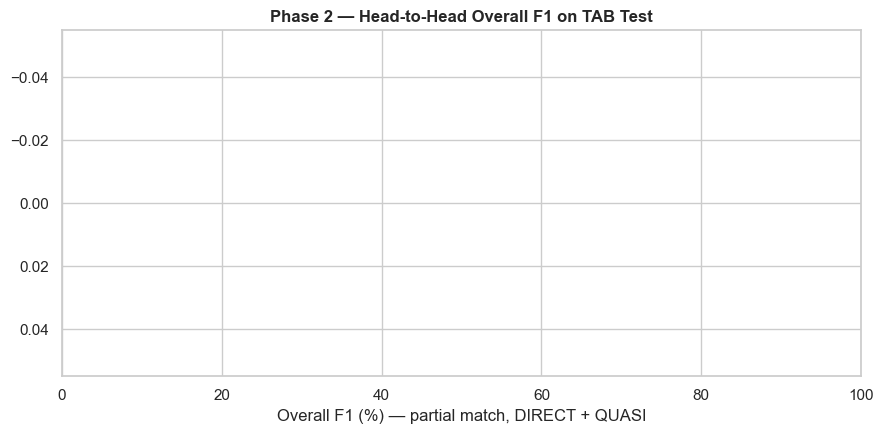

In [3]:
order = ["spacy_trf", "hf_bert_base_ner", "presidio_stock", "presidio_plus_case_number", "roberta_finetuned_tab"]
labels = {
    "spacy_trf":                "spaCy en_core_web_trf",
    "hf_bert_base_ner":         "HF bert-base-NER",
    "presidio_stock":           "Presidio (stock)",
    "presidio_plus_case_number":"Presidio + CASE_NUMBER",
    "roberta_finetuned_tab":    "RoBERTa (fine-tuned)",
}
colors = {
    "spacy_trf":                 "#95a5a6",
    "hf_bert_base_ner":          "#3498db",
    "presidio_stock":            "#9b59b6",
    "presidio_plus_case_number": "#8e44ad",
    "roberta_finetuned_tab":     "#27ae60",
}

overall = results[(results["mode"] == "partial") & (results["entity_type"] == "_ALL")]
overall = overall.set_index("model").reindex([m for m in order if m in overall.index]).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    [labels.get(m, m) for m in overall["model"]],
    overall["f1"] * 100,
    color=[colors.get(m, "#7f8c8d") for m in overall["model"]],
    edgecolor="white",
)
for bar, f1 in zip(bars, overall["f1"]):
    ax.text(f1 * 100 + 0.5, bar.get_y() + bar.get_height() / 2, f"{f1:.1%}",
            va="center", fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel("Overall F1 (%) — partial match, DIRECT + QUASI")
ax.set_title("Phase 2 — Head-to-Head Overall F1 on TAB Test", fontweight="bold")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig("../figures/phase2_overall_f1.png", dpi=120, bbox_inches="tight")
plt.show()


## F1 by entity type — where each model wins and loses


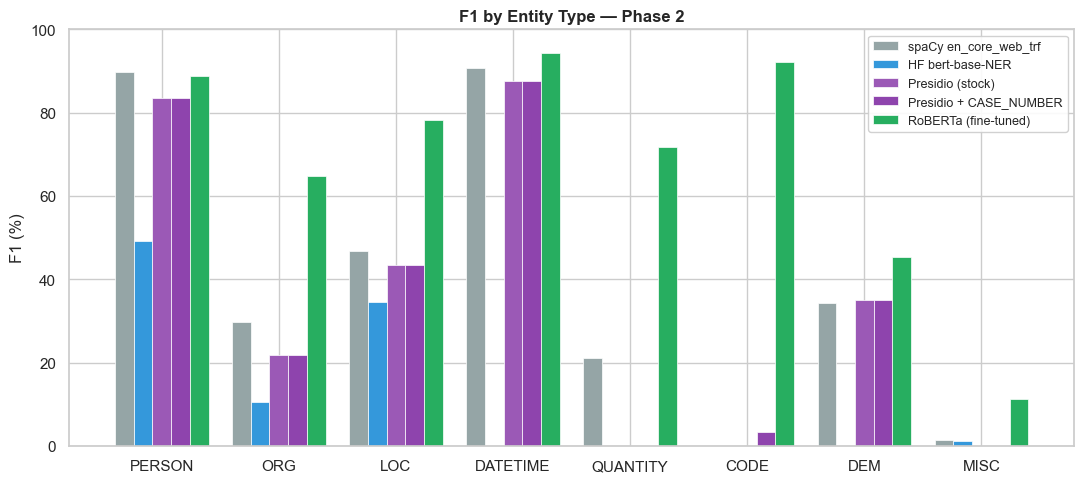

In [4]:
entity_order = ["PERSON", "ORG", "LOC", "DATETIME", "QUANTITY", "CODE", "DEM", "MISC"]
per_type = results[(results["mode"] == "partial") & (results["entity_type"].isin(entity_order))]

pivot = (per_type
         .pivot_table(index="entity_type", columns="model", values="f1")
         .reindex(entity_order))
# preserve column order
pivot = pivot.reindex(columns=[m for m in order if m in pivot.columns])

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(entity_order))
width = 0.8 / len(pivot.columns)
for i, model in enumerate(pivot.columns):
    offset = (i - (len(pivot.columns) - 1) / 2) * width
    vals = pivot[model].fillna(0).values * 100
    ax.bar([xi + offset for xi in x], vals, width=width,
           color=colors.get(model, "#7f8c8d"),
           label=labels.get(model, model),
           edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(entity_order)
ax.set_ylabel("F1 (%)")
ax.set_title("F1 by Entity Type — Phase 2", fontweight="bold")
ax.set_ylim(0, 100)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
fig.tight_layout()
fig.savefig("../figures/phase2_f1_by_entity.png", dpi=120, bbox_inches="tight")
plt.show()


## Where the fine-tune helps most


In [5]:
anchor = "spacy_trf"
contender = "roberta_finetuned_tab"

if anchor in pivot.columns and contender in pivot.columns:
    delta = ((pivot[contender] - pivot[anchor]) * 100).sort_values(ascending=False)
    print("F1 absolute improvement, RoBERTa fine-tune vs spaCy baseline:")
    print("─" * 50)
    for et, d in delta.items():
        bar = "█" * max(0, int(d / 2))
        sign = "+" if d >= 0 else ""
        print(f"  {et:10s}  {sign}{d:5.1f} pp   {bar}")
else:
    print("Need both phase-1 and fine-tune results to compute deltas.")


F1 absolute improvement, RoBERTa fine-tune vs spaCy baseline:
──────────────────────────────────────────────────
  CODE        + 92.2 pp   ██████████████████████████████████████████████
  QUANTITY    + 50.6 pp   █████████████████████████
  ORG         + 35.1 pp   █████████████████
  LOC         + 31.5 pp   ███████████████
  DEM         + 11.2 pp   █████
  MISC        +  9.8 pp   ████
  DATETIME    +  3.7 pp   █
  PERSON       -1.1 pp   


## What the comparison answers

Three things should fall out of these plots, regardless of the exact numbers:

1. **General-purpose models cluster together.** spaCy, HF bert-base-NER, and stock Presidio will all sit around 0.5–0.6 overall F1 — they share a label set that doesn't quite fit TAB.
2. **Targeted regex closes targeted gaps.** The `+CASE_NUMBER` Presidio variant should pull dramatically ahead on `CODE` recall, but otherwise look the same as stock — confirming that regex layers complement NER rather than replacing it.
3. **Fine-tuning dominates on TAB-specific labels.** RoBERTa fine-tuned on TAB train should be the clear leader on `CODE`, `DEM`, and `MISC`. Whether it also wins on `PERSON` and `ORG` is the interesting empirical question — both versions of the answer say something useful in the writeup.

Bring these three figures into `writeup/README.md` to fold the Phase 2 section in.
